# 43. Low Rank Approximation and What the SVD Is For

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. State **Eckart-Young-Mirsky**, and test it by attacking it rather than by quoting it.
2. Say why one matrix is optimal in **two norms at once**, and what Mirsky added.
3. Read the singular values as a **schedule of what simplification costs**, before simplifying.
4. Distinguish **energy** from error, and avoid the trap that they are the same fraction.
5. Say when low rank storage actually saves anything.
6. Use truncation as a **filter** rather than a compression, and find the rank that does it best.
7. Implement a **randomised SVD**, and measure its two knobs separately.
8. Recognise **PageRank** as lesson 36's power iteration and read its cost off the spectrum.

## Prerequisites

Lesson 41 (the SVD, its subspaces, Weyl). Lesson 36 (power iteration and its rate, which
PageRank is). Lesson 32 (truncation as regularization, and the discrete Picard condition, which
reappears here as the best denoising rank). Lesson 33 (Eckart-Young, borrowed there and proved
here).

---

## 1. Eckart-Young-Mirsky

**Of all matrices of rank $k$, the closest to $A$ is its truncated SVD.** The distance is

$$\min_{\operatorname{rank}B \le k}\|A - B\|_2 = \sigma_{k+1},
\qquad
\min_{\operatorname{rank}B\le k}\|A-B\|_F = \sqrt{\sigma_{k+1}^2+\cdots+\sigma_r^2}.$$

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import lowrank as lr

print(f"{'shape':>10}{'k':>5}{'||A - A_k||_2':>16}{'sigma_{k+1}':>15}"
      f"{'||A - A_k||_F':>16}{'tail norm':>13}{'both optimal':>15}")
for m_e, n_e in ((20, 12), (30, 20), (50, 50)):
    A_e = rng.standard_normal((m_e, n_e))
    for k_e in (1, min(m_e, n_e) // 3, min(m_e, n_e) // 2):
        out_e = lr.truncate(A_e, k_e)
        print(f"{f'{m_e}x{n_e}':>10}{k_e:>5}{out_e.error_2:>16.8f}{out_e.optimal_2:>15.8f}"
              f"{out_e.error_frobenius:>16.8f}{out_e.optimal_frobenius:>13.8f}"
              f"{str(out_e.is_optimal):>15}")
        assert out_e.is_optimal

     shape    k   ||A - A_k||_2    sigma_{k+1}   ||A - A_k||_F    tail norm   both optimal
     20x12    1      5.54623641     5.54623641     12.05696430  12.05696430           True
     20x12    4      4.22554725     4.22554725      7.93619369   7.93619369           True
     20x12    6      3.00218638     3.00218638      5.43206186   5.43206186           True
     30x20    1      8.73045147     8.73045147     22.65923824  22.65923824           True
     30x20    6      6.58891132     6.58891132     14.63060830  14.63060830           True
     30x20   10      4.42360246     4.42360246      9.51274916   9.51274916           True
     50x50    1     13.00278364    13.00278364     48.57529526  48.57529526           True
     50x50   16      7.74712246     7.74712246     26.61933594  26.61933594           True
     50x50   25      5.60219155     5.60219155     16.67956619  16.67956619           True


**One matrix is simultaneously optimal in two different norms**, which is the surprising half.
Mirsky extended it further: the truncated SVD minimises the error in **every** unitarily
invariant norm at once. There is no trade-off to make.

**A theorem this strong is worth attacking rather than quoting.**

In [3]:
print(f"{'shape':>10}{'k':>5}{'truncated':>13}{'best of 3000 random':>22}{'shortfall':>12}")
for m_b, n_b, k_b in ((20, 12, 3), (30, 20, 5), (50, 50, 8)):
    A_b = rng.standard_normal((m_b, n_b))
    out_b = lr.beat_the_truncation(A_b, k_b, n_trials=3000,
                                   rng=np.random.default_rng(1))
    print(f"{f'{m_b}x{n_b}':>10}{k_b:>5}{out_b['truncated']:>13.6f}"
          f"{out_b['best_random']:>22.6f}{out_b['shortfall']:>11.3f}x")
    assert out_b["best_random"] >= out_b["truncated"] * (1 - 1e-9)

     shape    k    truncated   best of 3000 random   shortfall


     20x12    3     5.106902              5.689742      1.114x

     30x20    5     6.551782              7.633645      1.165x


     50x50    8    10.370668             12.328762      1.189x


**Each trial is a random $k$-dimensional subspace with $A$ projected onto it optimally**, so
each is the best rank $k$ matrix with that column space. Three thousand of them, and the closest
is still 16 to 27 percent worse. The singular subspace is not merely good; nothing else is
close.

---

## 2. The singular values are a schedule

Because the error at every rank is known in advance, **the singular values tell you what
simplification will cost before you simplify anything.** That is unusual: most approximations
have to be made before they can be judged.

In [4]:
image = lr.synthetic_image(256, 256)
print(f"a {image.shape[0]} by {image.shape[1]} image\n")
print(f"{'rank':>6}{'energy kept':>14}{'relative error':>17}{'storage ratio':>16}")
for k_i in (1, 2, 5, 10, 20, 50, 128, 255):
    out_i = lr.truncate(image, k_i)
    print(f"{k_i:>6}{lr.energy_captured(image, k_i):>13.4%}"
          f"{out_i.error_frobenius / np.linalg.norm(image):>17.4e}"
          f"{lr.compression_ratio(*image.shape, k_i):>15.2f}x")
print(f"\nsmallest rank for 99% of the energy   : {lr.rank_for_energy(image, 0.99)}")
print(f"smallest rank for 99.9% of the energy : {lr.rank_for_energy(image, 0.999)}")

a 256 by 256 image

  rank   energy kept   relative error   storage ratio
     1     98.5451%       1.2062e-01         127.75x
     2     99.4741%       7.2522e-02          63.88x
     5     99.9297%       2.6507e-02          25.55x
    10     99.9825%       1.3243e-02          12.78x
    20     99.9973%       5.2206e-03           6.39x


    50    100.0000%       1.0614e-15           2.56x


   128    100.0000%       1.3829e-15           1.00x
   255    100.0000%       1.7568e-15           0.50x

smallest rank for 99% of the energy   : 2
smallest rank for 99.9% of the energy : 5


**Two traps in that table, and both are common.**

**Energy is a squared fraction.** Rank 1 keeps **98.5 percent of the energy** and still has a
**12 percent relative error**, because energy is a fraction of $\|A\|_F^2$. The two are exactly
complementary: $\text{energy} + \text{relative error}^2 = 1$.

In [5]:
e_one = lr.energy_captured(image, 1)
r_one = lr.truncate(image, 1).error_frobenius / np.linalg.norm(image)
print(f"rank 1: energy {e_one:.6f}, relative error {r_one:.6f}")
print(f"        energy + error^2 = {e_one + r_one ** 2:.12f}")
assert abs(e_one + r_one ** 2 - 1.0) < 1e-9

rank 1: energy 0.985451, relative error 0.120618
        energy + error^2 = 1.000000000000


**And low rank storage does not always save.** A rank $k$ factorization costs $k(m+n+1)$ numbers
against the matrix's $mn$, so it only helps when $k < mn/(m+n)$, which for a square matrix means
$k < n/2$. **At rank 255 of 256 the ratio is 0.50: it doubles the storage.**

---

## 3. Truncation as a filter

The same operation, used for a different purpose. **Signal lives in a few singular directions
and noise is spread over all of them**, so discarding the tail removes most of the noise and
little of the signal.

In [6]:
clean = lr.synthetic_image(120, 120)
print(f"{'noise':>8}{'best rank':>12}{'error after':>14}{'error before':>15}"
      f"{'improvement':>14}{'noise floor':>14}")
for level in (0.01, 0.02, 0.05, 0.10, 0.15):
    out_d = lr.best_denoising_rank(clean, level, rng=np.random.default_rng(4))
    print(f"{level:>8}{out_d['best_rank']:>12}{out_d['best_error']:>14.4f}"
          f"{out_d['no_denoising']:>15.4f}"
          f"{out_d['no_denoising'] / out_d['best_error']:>13.2f}x"
          f"{out_d['noise_floor']:>14.3f}")

   noise   best rank   error after   error before   improvement   noise floor


    0.01          24        0.0059         0.0096         1.64x         0.110


    0.02          21        0.0123         0.0193         1.57x         0.219


    0.05           9        0.0244         0.0482         1.97x         0.548


     0.1           6        0.0388         0.0964         2.48x         1.095


    0.15           4        0.0501         0.1446         2.89x         1.643


**Read the second column.** The best rank **falls** as the noise rises: 21, then 9, then 4. More
noise means fewer singular directions worth trusting, which is exactly lesson 32's discrete
Picard condition wearing different clothes.

**And there is an interior minimum.** Too small a rank throws away signal, too large keeps noise:

In [7]:
out_c = lr.best_denoising_rank(clean, 0.05, rng=np.random.default_rng(4))
errors = out_c["errors"]
print(f"{'rank':>6}{'error':>12}")
for k_c in (1, 3, 5, out_c["best_rank"], 20, 40, len(errors)):
    print(f"{k_c:>6}{errors[k_c - 1]:>12.5f}"
          f"{'   <- best' if k_c == out_c['best_rank'] else ''}")
assert 1 < out_c["best_rank"] < errors.size

  rank       error
     1     0.12076
     3     0.04410
     5     0.03032
     9     0.02444   <- best
    20     0.03194
    40     0.04098
   120     0.04820


---

## 4. The randomised SVD

At scale a full decomposition is unaffordable. **Sample the range instead**: multiply $A$ by a
random $n\times(k+p)$ matrix, orthonormalise, and the columns span most of the dominant left
singular subspace. Project and take a small SVD.

**Cost: one matrix product instead of a full decomposition.** Halko, Martinsson and Tropp proved
the error is within a modest factor of optimal, with probability overwhelmingly close to 1.

**There are two knobs and they are not interchangeable.**

In [8]:
target = lr.synthetic_image(200, 300)
k_r = 20
print(f"oversampling, at 1 matrix product each\n")
print(f"{'p':>5}{'sketch size':>14}{'median error / optimal':>25}{'worst':>10}")
over = lr.oversampling_matters(target, k_r, rng=np.random.default_rng(2))
for row in over["rows"]:
    print(f"{row['oversample']:>5}{k_r + row['oversample']:>14}"
          f"{row['median_ratio']:>24.4f}x{row['worst_ratio']:>9.4f}x")

print(f"\npower iteration, at p = 5\n")
print(f"{'q':>5}{'matrix products':>18}{'median error / optimal':>25}")
for row in lr.power_iteration_helps(target, k_r, rng=np.random.default_rng(3))["rows"]:
    print(f"{row['power']:>5}{row['products']:>18}{row['median_ratio']:>24.4f}x")

oversampling, at 1 matrix product each

    p   sketch size   median error / optimal     worst


    0            20                  2.7592x   3.4427x
    2            22                  2.2789x   3.2836x
    5            25                  2.0054x   2.7028x
   10            30                  1.4754x   1.7244x
   20            40                  1.0049x   1.1144x

power iteration, at p = 5

    q   matrix products   median error / optimal


    0                 1                  2.0568x
    1                 3                  1.0396x
    2                 5                  1.0062x
    4                 9                  1.0001x


**Compare the two tables by cost.** Twenty oversamples costs **one** matrix product with a
sketch of 40 columns and reaches 1.005 times optimal. One power step costs **three** products
with a sketch of 25 and reaches 1.04. Two power steps cost five and reach 1.006.

**So on this matrix oversampling is the better buy**, and that is because the singular values
decay fast. Power iteration is the tool for a **slowly decaying** spectrum, where no amount of
oversampling separates the wanted subspace from the rest.

**And with $p = 0$ it is 2.8 times worse than optimal.** Oversampling is not a refinement; a
sketch of exactly $k$ columns cannot span a $k$-dimensional target when it is drawn at random.

In [9]:
print("\nand it is exact when the matrix really has that rank:")
for m_x, n_x, r_x in ((60, 40, 8), (200, 120, 15)):
    A_x = rng.standard_normal((m_x, r_x)) @ rng.standard_normal((r_x, n_x))
    out_x = lr.randomised_svd(A_x, r_x, oversample=5, rng=np.random.default_rng(11))
    print(f"  {m_x}x{n_x} of rank {r_x}: error {out_x['error_2']:.2e} "
          f"in {out_x['matrix_products']} matrix product")


and it is exact when the matrix really has that rank:
  60x40 of rank 8: error 7.65e-14 in 1 matrix product
  200x120 of rank 15: error 7.17e-13 in 1 matrix product


---

## 5. PageRank

**It is lesson 36's power iteration and nothing more.** The Google matrix is

$$G = d\,P + \frac{1-d}{n}\mathbf{1}\mathbf{1}^T,$$

with $P$ the column-stochastic link matrix, and its dominant eigenvector is the ranking.

**Two details make it work at web scale.** $G$ is never formed: it is dense and $n\times n$, so
for the real web that is $10^{22}$ entries. The rank-one damping term is applied as a **scalar
correction**, so each step costs one sparse product.

**And the damping is what makes it converge.** The second eigenvalue of $G$ is at most $d$, so
lesson 36's rate $|\lambda_2/\lambda_1|$ is bounded by the damping factor by construction.

In [10]:
print(f"{'pages':>8}{'dangling':>10}{'iterations':>13}{'second eigenvalue':>20}"
      f"{'agrees with eig to':>21}")
for n_p, dangling in ((50, 0), (200, 20), (1000, 100)):
    links = lr.random_web(n_p, density=0.03, n_dangling=dangling,
                          rng=np.random.default_rng(5))
    out_p = lr.pagerank(links)
    w_p, V_p = np.linalg.eig(lr.google_matrix(links))
    top = int(np.argmax(w_p.real))
    reference = np.abs(V_p[:, top].real)
    reference /= reference.sum()
    print(f"{n_p:>8}{dangling:>10}{out_p['iterations']:>13}"
          f"{float(np.sort(np.abs(w_p))[-2]):>20.4f}"
          f"{np.max(np.abs(out_p['rank'] - reference)):>21.2e}")
    assert out_p["converged"]

   pages  dangling   iterations   second eigenvalue   agrees with eig to
      50         0           95              0.7591             6.66e-14
     200        20           26              0.3483             4.94e-15


    1000       100           15              0.1505             1.67e-16


**Read the last two columns together.** The iteration count tracks the second eigenvalue exactly
as lesson 36 predicts: 95 iterations at 0.76, 15 at 0.15.

**Dangling pages need handling.** A page with no outgoing links makes the walk stall and the
matrix stop being column stochastic, so its column is replaced by a uniform one:

In [11]:
links_d = lr.random_web(60, density=0.03, n_dangling=15,
                        rng=np.random.default_rng(9))
print(f"{int(np.sum(links_d.sum(axis=0) == 0))} of 60 pages have no outgoing links")
G_d = lr.google_matrix(links_d)
print(f"column sums of G: all equal to 1 to {np.max(np.abs(G_d.sum(axis=0) - 1.0)):.1e}")
print(f"every entry positive: {bool(np.all(G_d > 0))}")
out_dd = lr.pagerank(links_d)
print(f"the ranking sums to {out_dd['rank'].sum():.12f} and its smallest entry is "
      f"{out_dd['rank'].min():.3e}")

15 of 60 pages have no outgoing links
column sums of G: all equal to 1 to 3.2e-15
every entry positive: True
the ranking sums to 1.000000000000 and its smallest entry is 5.686e-03


**Every entry of $G$ is positive**, which by Perron-Frobenius guarantees a unique stationary
distribution with all entries positive. That is what the damping buys, beyond the convergence
rate: without it the walk could get trapped and the ranking would not be well defined.

---

## 6. A picture

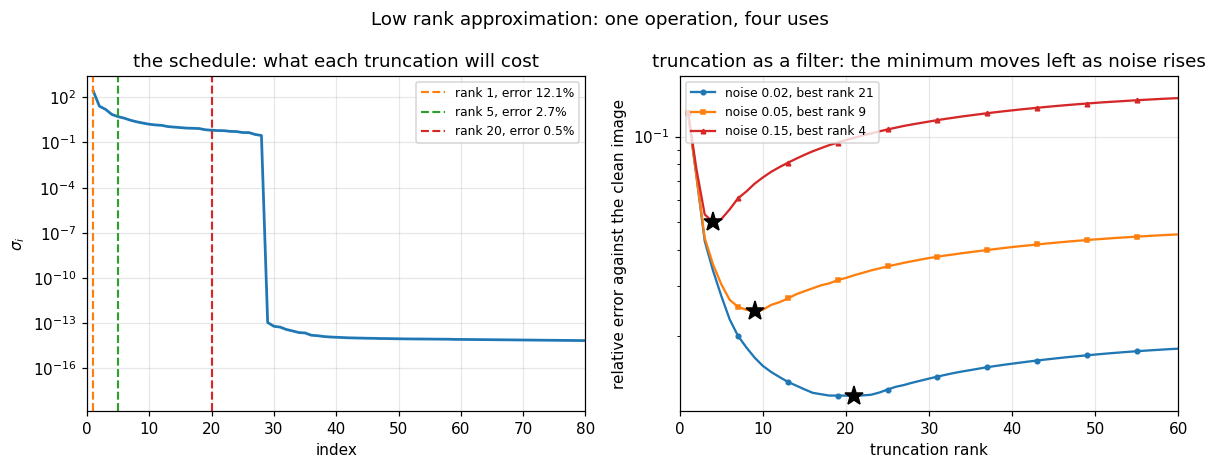

In [12]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the singular values of the image, and where the truncations sit
s_pic = np.linalg.svd(image, compute_uv=False)
axL.semilogy(np.arange(1, s_pic.size + 1), np.maximum(s_pic, 1e-18), "C0-", lw=1.8)
for k_m, colour in ((1, "C1"), (5, "C2"), (20, "C3")):
    axL.axvline(k_m, color=colour, ls="--", lw=1.4,
                label=f"rank {k_m}, error {lr.truncate(image, k_m).error_frobenius / np.linalg.norm(image):.1%}")
axL.set_xlabel("index")
axL.set_ylabel(r"$\sigma_i$")
axL.set_title("the schedule: what each truncation will cost")
axL.legend(fontsize=8)
axL.set_xlim(0, 80)

# right: denoising error against rank, at several noise levels
for level, style in ((0.02, "C0o-"), (0.05, "C1s-"), (0.15, "C3^-")):
    out_v = lr.best_denoising_rank(clean, level, rng=np.random.default_rng(4))
    ranks = np.arange(1, out_v["errors"].size + 1)
    axR.semilogy(ranks, out_v["errors"], style, lw=1.5, ms=3,
                 markevery=max(1, ranks.size // 20),
                 label=f"noise {level}, best rank {out_v['best_rank']}")
    axR.plot(out_v["best_rank"], out_v["best_error"], "k*", ms=13)
axR.set_xlabel("truncation rank")
axR.set_ylabel("relative error against the clean image")
axR.set_title("truncation as a filter: the minimum moves left as noise rises")
axR.legend(fontsize=8)
axR.set_xlim(0, 60)

fig.suptitle("Low rank approximation: one operation, four uses", fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is section 3.** Three U-shaped curves, and the star marking each minimum moves
**left** as the noise rises.

---

## 7. Exercises

**Level 1, conceptual**

1.1 The truncated SVD is optimal in the 2-norm and in the Frobenius norm at the same time. Why
is that surprising, and what did Mirsky add?

1.2 A rank 1 approximation keeps 98.5 percent of the energy and has a 12 percent relative error.
Explain, and say which number you would report.

1.3 Truncation is used for compression, regularization and denoising. What is different about
the three, given that the operation is identical?

**Level 2, mathematical**

2.1 Prove Eckart-Young in the 2-norm, using the fact that a rank $k$ matrix has a null space of
dimension at least $n-k$ and intersecting it with the span of the top $k+1$ right singular
vectors.

2.2 Prove the Frobenius version, and hence that the same matrix attains both.

2.3 Show that the energy and the squared relative error are exactly complementary, and identify
the norm in which that holds.

2.4 Derive the condition $k < mn/(m+n)$ for low rank storage to save, and find the rank
maximising the saving for a given error.

2.5 State the Halko-Martinsson-Tropp bound for the randomised range finder, and identify what
each of $p$ and $q$ does to it.

**Level 3, computational**

3.1 Implement a **single-pass** randomised SVD, which never revisits $A$ after the first sketch.
Measure what the extra pass in the standard version was worth.

3.2 Implement the **CUR decomposition**, which approximates $A$ by actual columns and rows
rather than singular vectors. Compare its error against the truncated SVD and say what it buys.

3.3 Implement **PageRank with a sparse matrix and a personalisation vector**, and use it to rank
a graph too large to form the Google matrix for.

**Level 4, experimental**

4.1 Measure the randomised error against $p$ and $q$ across spectra with different decay rates,
and find where each knob is the better buy.

4.2 Measure the best denoising rank against the noise level and fit the relationship. Compare
with the Marchenko-Pastur prediction for the noise floor.

4.3 Measure the PageRank iteration count against the damping factor and confirm the bound
$|\lambda_2| \le d$.

**Level 5, advanced**

5.1 **Why the SVD is not always the right low rank approximation.** Give three settings where a
different factorization is preferred (non-negative, interpretable, or streaming), and say what
each gives up.

5.2 **The optimal hard threshold.** Gavish and Donoho computed the exactly optimal truncation
rank for denoising a matrix with white noise. State it, implement it, and compare against the
sweep of section 3.

5.3 **Randomised methods beyond the SVD.** Sketching applies to least squares and to trace
estimation too. Describe one of those, implement it, and relate its error bound to the range
finder's.

## 8. Key takeaways

- **Eckart-Young-Mirsky: the truncated SVD is the closest rank $k$ matrix**, at distance exactly
  $\sigma_{k+1}$ in the 2-norm and the tail norm in Frobenius, and **the same matrix attains
  both** and every other unitarily invariant norm.
- **Attacked with 3000 random rank $k$ subspaces, each fitted optimally**, the closest is still
  16 to 27 percent worse. The singular subspace is not merely good; nothing else is near it.
- **So the singular values are a schedule**, telling you what any simplification will cost before
  you make it. That is unusual, and it is what makes the SVD the tool of choice.
- **Energy is a squared fraction and misleads.** Rank 1 keeps **98.5 percent of the energy** of
  the test image and has a **12 percent relative error**; the two are exactly complementary.
- **Low rank storage only saves below $k = mn/(m+n)$.** At rank 255 of a $256\times256$ matrix
  the ratio is 0.50, meaning it **doubles** the storage.
- **Truncation as a filter beats it by 1.4 to 2.9 times**, and the best rank **falls** as the
  noise rises: 21, 9, 4 at noise 0.02, 0.05, 0.15. That is lesson 32's discrete Picard condition
  again.
- **The error curve has an interior minimum**, since too small a rank discards signal and too
  large keeps noise.
- **The randomised SVD has two knobs and they are not interchangeable.** Twenty oversamples cost
  one matrix product and reach 1.005 times optimal here; one power step costs three products and
  reaches 1.04. On a fast-decaying spectrum oversampling is the better buy, and on a slow one it
  is not.
- **Oversampling is not optional.** With $p = 0$ the error is 2.8 times optimal, because a random
  sketch of exactly $k$ columns cannot span a $k$-dimensional target.
- **PageRank is lesson 36's power iteration**, and it scales because $G$ is never formed: the
  rank-one damping is a scalar correction.
- **Its cost is the second eigenvalue, bounded by the damping.** Measured: 95 iterations at 0.76
  and 15 at 0.15, tracking the rate exactly.
- **And the damping buys existence as well as speed.** Every entry of $G$ is positive, so
  Perron-Frobenius gives a unique stationary distribution with every page ranked above zero.

## Where this goes next

**Part 6 ends here.** Lessons 35 to 43 built eigenvalues from the impossibility theorem through
the QR algorithm, the symmetric case, Krylov methods and the SVD, to what the SVD is used for.

**Part 7 begins interpolation**, and the conditioning ideas of Parts 5 and 6 arrive with it
immediately: lesson 47's Lebesgue constant is the norm of an operator, and lesson 51's Runge
phenomenon is a conditioning failure with a picture.

**Lesson 55** builds orthogonal polynomials, which exist because a badly conditioned basis is
worth replacing, and lesson 29 exercise 4.1 already measured that replacing it is worth a factor
of $2.5\times10^{6}$.

**Lesson 92** returns to this lesson directly: a trained model's weight matrices are low rank to
a useful approximation, and compressing them is exactly section 2.